In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
df = sns.load_dataset("healthexp")
df.head()

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9


1-Déterminez quelles sont les variables Discrètes et Continues du dataset

In [3]:
df.dtypes

Year                 int64
Country             object
Spending_USD       float64
Life_Expectancy    float64
dtype: object

2-Analysez la variable "Country".

In [4]:
df["Country"].value_counts()

Country
USA              51
Japan            51
Germany          50
Canada           44
Great Britain    43
France           35
Name: count, dtype: int64

<Axes: xlabel='Country'>

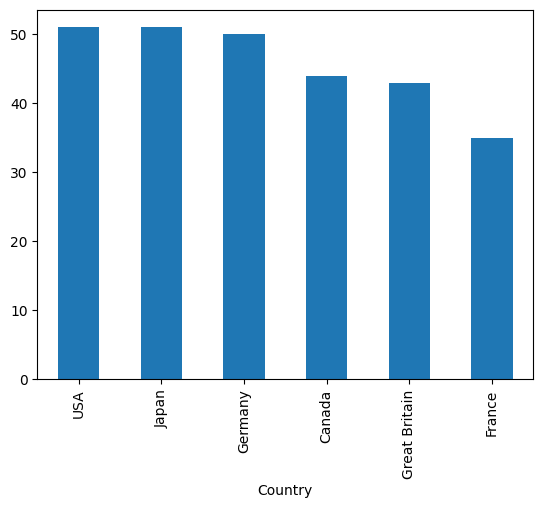

In [5]:
df["Country"].value_counts().plot(kind="bar")

3-Analysez la variable "Spending_USD".

In [6]:
df["Spending_USD"].describe()

count      274.000000
mean      2789.338905
std       2194.939785
min        123.993000
25%       1038.357000
50%       2295.578000
75%       4055.610000
max      11859.179000
Name: Spending_USD, dtype: float64

Text(0.5, 1.0, 'Boxplot of Spending USD')

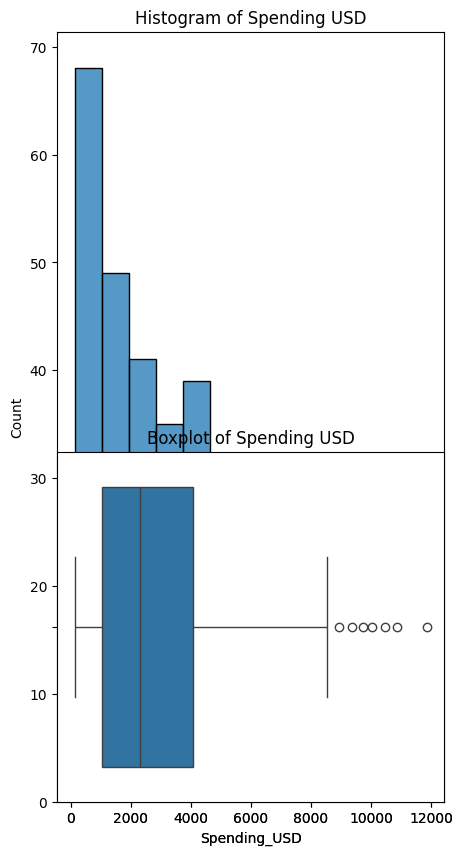

In [7]:
plt.figure(figsize=(5,10))

# Histogram
plt.subplot(1, 1, 1)
sns.histplot(df['Spending_USD'])
plt.title("Histogram of Spending USD")

# Boxplot
plt.subplot(2, 1, 2)
sns.boxplot(x=df['Spending_USD'])
plt.title("Boxplot of Spending USD")

4-Analysez la variable "Life_Expectancy".

In [8]:
df["Life_Expectancy"].describe()

count    274.000000
mean      77.909489
std        3.276263
min       70.600000
25%       75.525000
50%       78.100000
75%       80.575000
max       84.700000
Name: Life_Expectancy, dtype: float64

Text(0.5, 1.0, 'Boxplot of Life Expectancy')

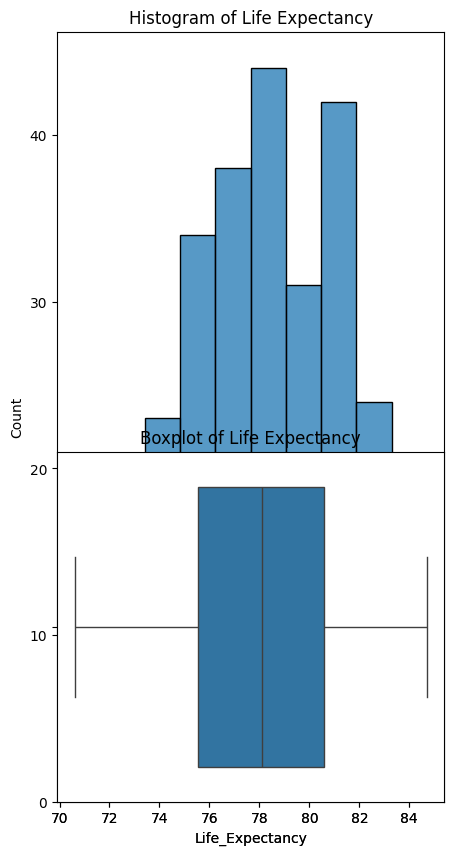

In [9]:


plt.figure(figsize=(5,10))

# Histogram
plt.subplot(1, 1, 1)
sns.histplot(df["Life_Expectancy"])
plt.title("Histogram of Life Expectancy")

# Boxplot
plt.subplot(2, 1, 2)
sns.boxplot(x=df["Life_Expectancy"])
plt.title("Boxplot of Life Expectancy")


2-Observez l'évolution de la durée de vie à travers le temps.

<Axes: xlabel='Year', ylabel='Life_Expectancy'>

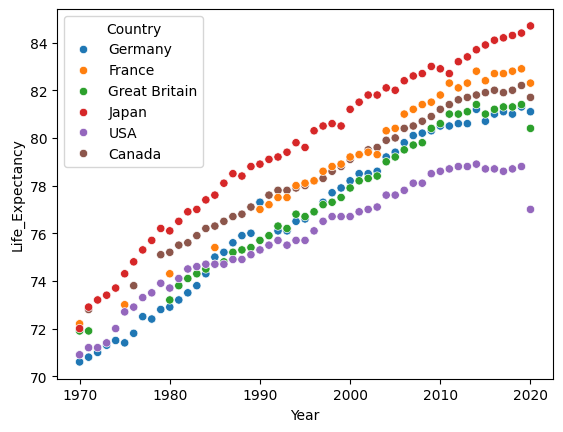

In [10]:
# df.groupby('Year')['Life_Expectancy'].mean().plot(kind='bar')
# sns.scatterplot(data=df, x=df['Year'], y=df['Life_Expectancy'])
sns.scatterplot(data=df, x='Year', y='Life_Expectancy', hue='Country')

1-Observez l'évolution des dépenses en santé de l'Allemagne et de la Grande Bretagne à travers le temps.

<Axes: xlabel='Year', ylabel='Life_Expectancy'>

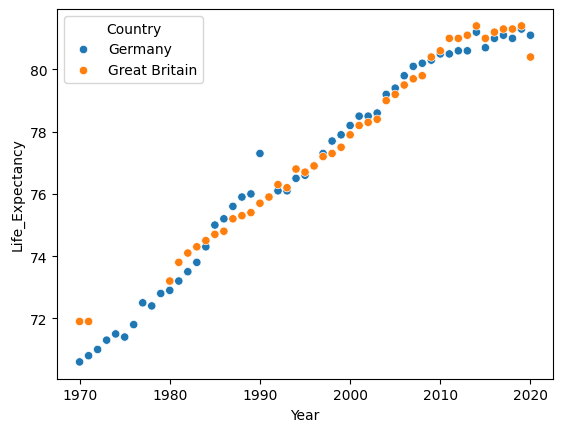

In [11]:
sns.scatterplot(data=df.query ("`Country` == 'Germany' | `Country` == 'Great Britain'"), x='Year', y='Life_Expectancy', hue='Country')

2-Observez l'histogramme, la boxplot, et les statistiques de "Life_Expectancy" propre à chaque pays.

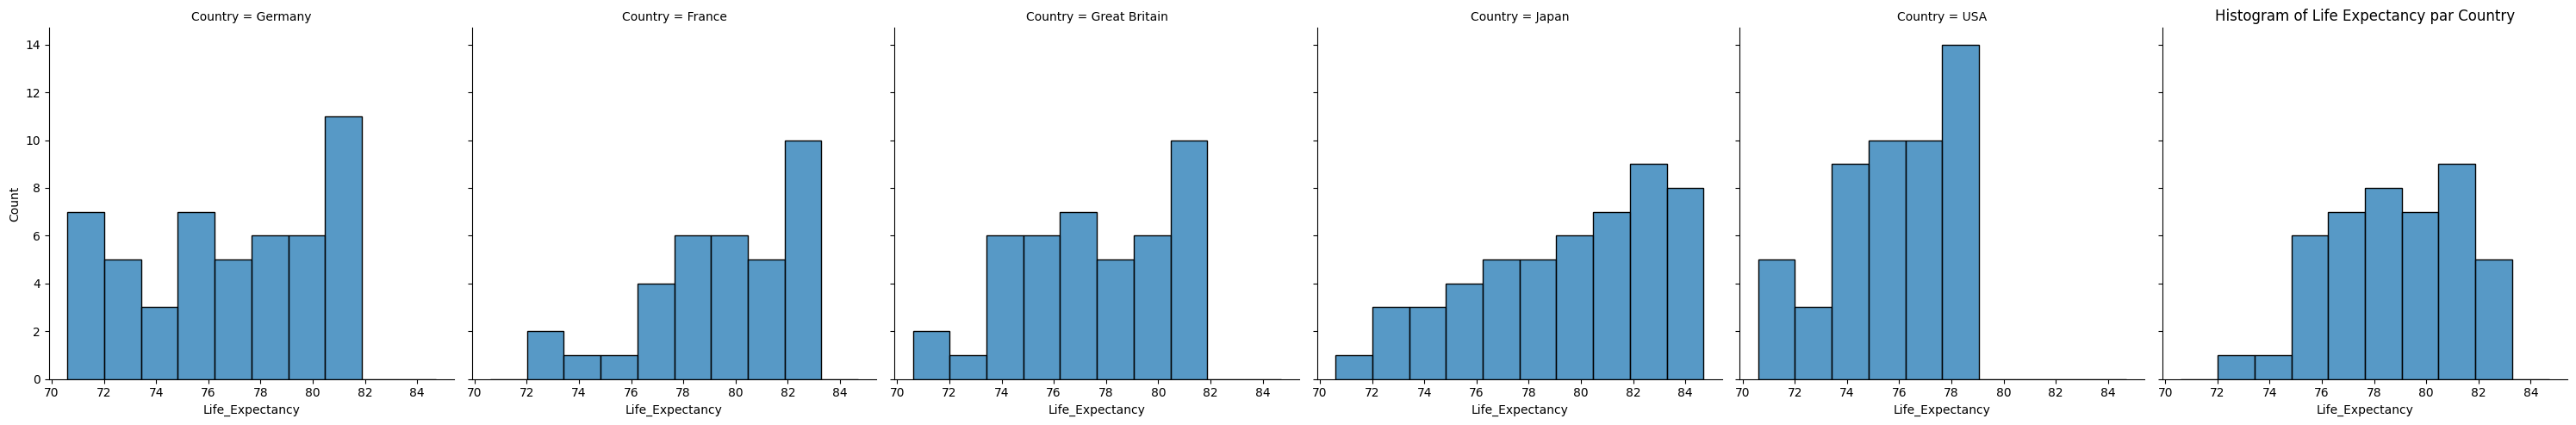

In [12]:
sns.displot(data=df,x='Life_Expectancy',col='Country')
plt.title("Histogram of Life Expectancy par Country")
plt.show()


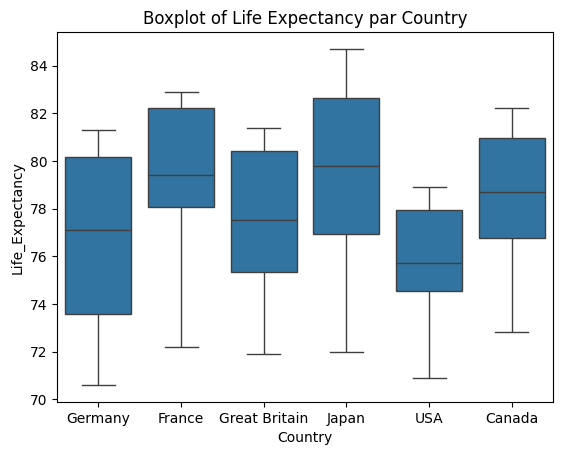

In [13]:
# Boxplot

sns.boxplot(x='Country', y='Life_Expectancy', data=df) 
plt.title("Boxplot of Life Expectancy par Country")
plt.show()

3-Observez la relation entre la durée de vie et les dépenses dans la santé, aux États-Unis, de 2000 à 2020

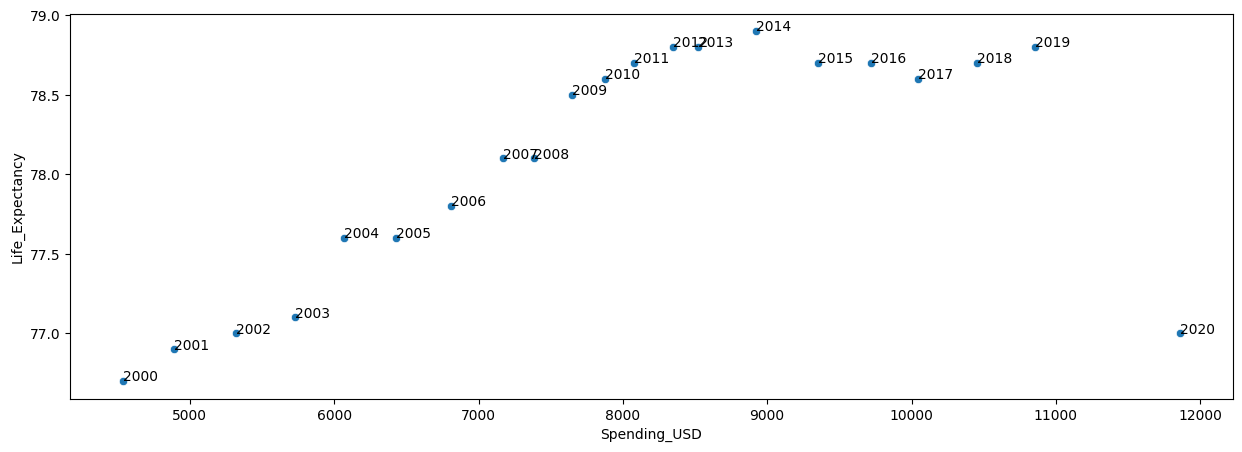

In [14]:
plt.figure(figsize=(15,5))
df_us = df[df['Country'] == 'USA']
dfus_20202000= df_us[(df_us['Year'] <= 2020) & (df_us['Year'] >= 2000)]
sns.scatterplot(data=dfus_20202000, y='Life_Expectancy', x='Spending_USD')

for i in range(len(dfus_20202000)):
    plt.text(
        dfus_20202000['Spending_USD'].iloc[i],
        dfus_20202000['Life_Expectancy'].iloc[i],
        str(dfus_20202000['Year'].iloc[i]),
        fontsize=10
    )

4-Il y a une valeur abérante tant tout cela. Laquelle? Pourquoi?

1-Calculez la corrélation de Pearson entre ces deux variables aux États-Unis (2000–2020).

In [15]:
from scipy.stats import pearsonr
df_us = df[df['Country'] == 'USA']
dfus_20202000= df_us[(df_us['Year'] <= 2020) & (df_us['Year'] >= 2000)]
pearsonr(dfus_20202000["Life_Expectancy"],dfus_20202000["Spending_USD"])

PearsonRResult(statistic=np.float64(0.6210674528998253), pvalue=np.float64(0.0026581544805799064))

2- Quelle serait la probabilité d'obtenir une corrélation au moins aussi importante que celle-ci, si en réalité les deux variables n'étaient pas corrélées ?
Corrélation (r)
proche de +1 → forte relation positive
proche de 0 → aucune relation
proche de -1 → relation négative

(Bonus) : Test d’hypothèse sur la durée de vie aux États-Unis

H0:la durée de vie aux Etas-Unis augmente en moyenne de 0.3

In [16]:
import seaborn as sns 
df =sns.load_dataset("tips")
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [17]:
from scipy.stats import chisquare
counts=df["day"].value_counts()
order = ['Thur', 'Fri', 'Sat','Sun']
f_obs = counts.reindex(order).values
total = len(df)
f_exp = [total*0.2, total*0.1, total*0.4, total*0.3]
chi,p=chisquare(f_obs=f_obs,f_exp=f_exp)
α=0.02
if p < α:
    print(" On rejette H0 (les proportions ne suivent pas la distribution attendue)")
else:
    print("On ne rejette pas H0 (les proportions suivent la distribution attendue)")

On ne rejette pas H0 (les proportions suivent la distribution attendue)


In [18]:
from scipy.stats import ttest_1samp
tips = df["tip"]
t_stat, p_value = ttest_1samp(tips,3.5)
print( p_value)
print("p-value : {:.10f}".format(p_value))

4.160537712307688e-08
p-value : 0.0000000416


In [19]:
import pandas as pd
from scipy.stats import chi2_contingency
table = pd.crosstab(df['day'], df['size'])
print(table)
chi2, p_val, dof, expected = chi2_contingency(table)

print(f"Statistique chi-deux : {chi2:.4f}")
print(f"P-value : {p_val:.4f}")



size  1   2   3   4  5  6
day                      
Thur  1  48   4   5  1  3
Fri   1  16   1   1  0  0
Sat   2  53  18  13  1  0
Sun   0  39  15  18  3  1
Statistique chi-deux : 29.6328
P-value : 0.0133


In [20]:
df = sns.load_dataset("mpg")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


🔹 Variables discrètes (valeurs entières / catégories)
cylinders → nombre de cylindres (4, 6, 8…)
origin → origine (USA, Europe, Japon)
model_year → année (70 → 82)
🔹 Variables continues (valeurs réelles)
mpg → consommation
horsepower → puissance
weight → poids
acceleration → accélération
displacement → cylindrée

In [21]:
df['mpg'].describe()

count    398.000000
mean      23.514573
std        7.815984
min        9.000000
25%       17.500000
50%       23.000000
75%       29.000000
max       46.600000
Name: mpg, dtype: float64

<Axes: xlabel='mpg', ylabel='Count'>

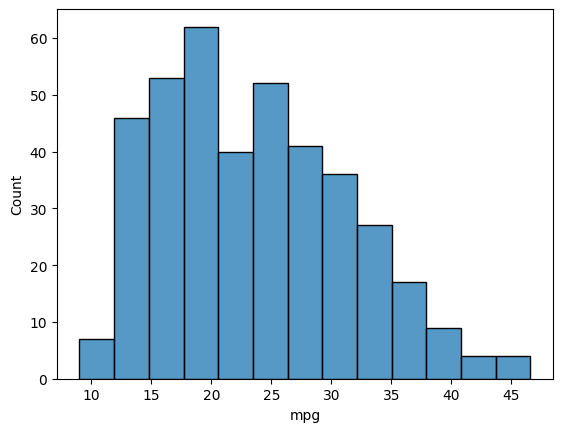

In [27]:

# sns.boxplot(x='mpg', data=df)
sns.histplot(x='mpg', data=df)

23 :Elle représente la consommation moyenne de toutes les voitures du dataset

In [28]:
df['cylinders'].value_counts()

cylinders
4    204
8    103
6     84
3      4
5      3
Name: count, dtype: int64

<Axes: xlabel='cylinders'>

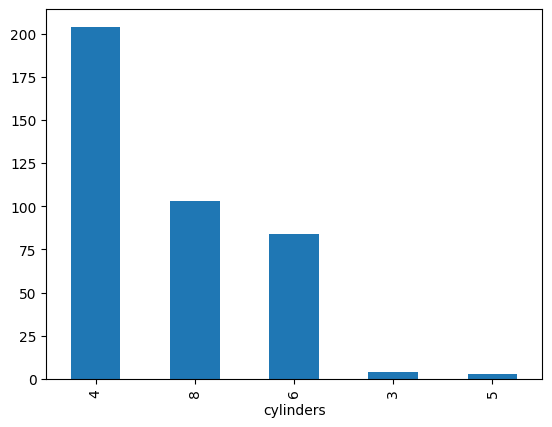

In [29]:
df["cylinders"].value_counts().plot(kind="bar")

In [30]:
df['origin'].value_counts()

origin
usa       249
japan      79
europe     70
Name: count, dtype: int64

<Axes: xlabel='origin'>

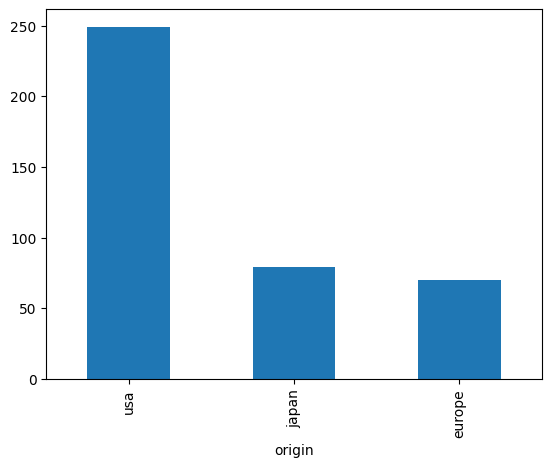

In [31]:
df["origin"].value_counts().plot(kind="bar")

<Axes: xlabel='mpg', ylabel='horsepower'>

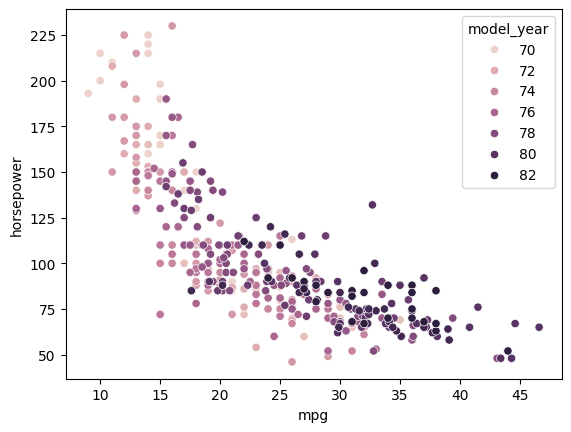

In [35]:
sns.scatterplot(data=df, x='mpg', y='horsepower', hue='model_year')

On observe une relation négative entre le horsepower et le mpg.

<Axes: xlabel='model_year'>

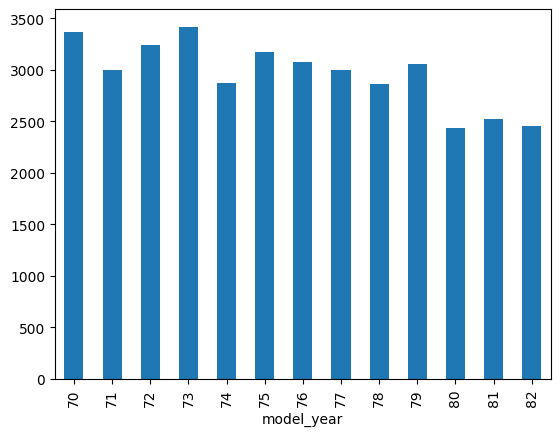

In [34]:
data=df[(df['model_year']>=70) & (df['model_year']<=82)]
data.groupby('model_year')['weight'].mean().plot(kind='bar')

On observe une diminution progressive du poids moyen des voitures entre 1970 et 1982. Les voitures étaient plus lourdes au début des années 70, puis deviennent progressivement plus légères, avec une baisse marquée à partir de la fin des années 70. Cela traduit une évolution vers des véhicules plus économiques et plus efficaces.

<Axes: xlabel='cylinders', ylabel='model_year'>

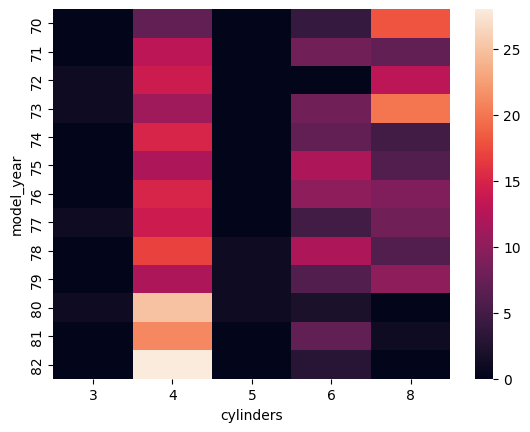

In [42]:
tab_Croi=pd.crosstab(df['model_year'], df['cylinders'])
sns.heatmap(tab_Croi)